**Pandas Tutorial covering core functionalities and plotting techniques.**

In [1]:
!pip install matplotlib seaborn scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Introduction to Pandas DataFrames

In [3]:

print("--- 1. Introduction to Pandas DataFrames ---")

# Creating a DataFrame from a dictionary
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Age': [24, 27, 22, 32, 29],
    'City': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix'],
    'Score': [85, 92, 78, 88, 95]
}
df = pd.DataFrame(data)
print("\nOriginal DataFrame (df):")
print(df)

--- 1. Introduction to Pandas DataFrames ---

Original DataFrame (df):
      Name  Age         City  Score
0    Alice   24     New York     85
1      Bob   27  Los Angeles     92
2  Charlie   22      Chicago     78
3    David   32      Houston     88
4      Eve   29      Phoenix     95


## Creating another DataFrame for demonstration

In [4]:

data2 = {
    'Name': ['Alice', 'Bob', 'Frank', 'Grace'],
    'Occupation': ['Engineer', 'Doctor', 'Artist', 'Teacher'],
    'City': ['New York', 'Los Angeles', 'Miami', 'Dallas']
}
df2 = pd.DataFrame(data2)
print("\nAnother DataFrame (df2):")
print(df2)


Another DataFrame (df2):
    Name Occupation         City
0  Alice   Engineer     New York
1    Bob     Doctor  Los Angeles
2  Frank     Artist        Miami
3  Grace    Teacher       Dallas


## Creating a third DataFrame for concatenation

In [5]:
data3 = {
    'Name': ['Hannah', 'Ivan'],
    'Age': [26, 30],
    'City': ['Seattle', 'Boston'],
    'Score': [90, 83]
}
df3 = pd.DataFrame(data3)

# 2. Merging, Joining, and Concatenation

In [6]:
print("\n--- 2. Merging, Joining, and Concatenation ---")

# Merging (based on common columns, like SQL JOIN)
# Inner Merge: Only rows with matching keys in both DataFrames
merged_inner = pd.merge(df, df2, on='Name', how='inner')
print("\nInner Merge (on 'Name'):")
print(merged_inner)



--- 2. Merging, Joining, and Concatenation ---

Inner Merge (on 'Name'):
    Name  Age       City_x  Score Occupation       City_y
0  Alice   24     New York     85   Engineer     New York
1    Bob   27  Los Angeles     92     Doctor  Los Angeles


In [7]:
# Left Merge: Include all rows from the left DataFrame, and matching from right
merged_left = pd.merge(df, df2, on='Name', how='left')
print("\nLeft Merge (on 'Name'):")
print(merged_left)



Left Merge (on 'Name'):
      Name  Age       City_x  Score Occupation       City_y
0    Alice   24     New York     85   Engineer     New York
1      Bob   27  Los Angeles     92     Doctor  Los Angeles
2  Charlie   22      Chicago     78        NaN          NaN
3    David   32      Houston     88        NaN          NaN
4      Eve   29      Phoenix     95        NaN          NaN


In [8]:
# Right Merge: Include all rows from the right DataFrame, and matching from left
merged_right = pd.merge(df, df2, on='Name', how='right')
print("\nRight Merge (on 'Name'):")
print(merged_right)

# Outer Merge: Include all rows from both DataFrames, filling NaN for non-matches
merged_outer = pd.merge(df, df2, on='Name', how='outer', suffixes=('_df1', '_df2'))
print("\nOuter Merge (on 'Name'):")
print(merged_outer)




Right Merge (on 'Name'):
    Name   Age       City_x  Score Occupation       City_y
0  Alice  24.0     New York   85.0   Engineer     New York
1    Bob  27.0  Los Angeles   92.0     Doctor  Los Angeles
2  Frank   NaN          NaN    NaN     Artist        Miami
3  Grace   NaN          NaN    NaN    Teacher       Dallas

Outer Merge (on 'Name'):
      Name   Age     City_df1  Score Occupation     City_df2
0    Alice  24.0     New York   85.0   Engineer     New York
1      Bob  27.0  Los Angeles   92.0     Doctor  Los Angeles
2  Charlie  22.0      Chicago   78.0        NaN          NaN
3    David  32.0      Houston   88.0        NaN          NaN
4      Eve  29.0      Phoenix   95.0        NaN          NaN
5    Frank   NaN          NaN    NaN     Artist        Miami
6    Grace   NaN          NaN    NaN    Teacher       Dallas


In [9]:
# Merging with multiple keys (using common columns 'Name' and 'City')
# To demonstrate, let's make a slight change in df2 for Charlie
df2_multi = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'City': ['New York', 'Los Angeles', 'Chicago', 'Houston'],
    'Project': ['A', 'B', 'C', 'D']
})
df_multi_merge = pd.merge(df, df2_multi, on=['Name', 'City'], how='inner')
print("\nInner Merge on multiple keys ('Name', 'City'):")
print(df_multi_merge)

# Joining (by index by default, or on a key column)
# df.join(other_df) joins on index if no 'on' parameter is specified.
# Let's set 'Name' as index for joining example
df_indexed = df.set_index('Name')
df2_indexed = df2.set_index('Name')

joined_df = df_indexed.join(df2_indexed, how='outer', lsuffix='_left', rsuffix='_right')
print("\nOuter Join (on index 'Name'):")
print(joined_df)


Inner Merge on multiple keys ('Name', 'City'):
      Name  Age         City  Score Project
0    Alice   24     New York     85       A
1      Bob   27  Los Angeles     92       B
2  Charlie   22      Chicago     78       C
3    David   32      Houston     88       D

Outer Join (on index 'Name'):
          Age    City_left  Score Occupation   City_right
Name                                                     
Alice    24.0     New York   85.0   Engineer     New York
Bob      27.0  Los Angeles   92.0     Doctor  Los Angeles
Charlie  22.0      Chicago   78.0        NaN          NaN
David    32.0      Houston   88.0        NaN          NaN
Eve      29.0      Phoenix   95.0        NaN          NaN
Frank     NaN          NaN    NaN     Artist        Miami
Grace     NaN          NaN    NaN    Teacher       Dallas


# Concatenation (stacking DataFrames vertically or horizontally)

In [10]:

# Concatenate vertically (by row)
concatenated_df = pd.concat([df, df3])
print("\nConcatenation (vertical - by row):")
print(concatenated_df)


Concatenation (vertical - by row):
      Name  Age         City  Score
0    Alice   24     New York     85
1      Bob   27  Los Angeles     92
2  Charlie   22      Chicago     78
3    David   32      Houston     88
4      Eve   29      Phoenix     95
0   Hannah   26      Seattle     90
1     Ivan   30       Boston     83


In [11]:
# Concatenate horizontally (by column)
df_part1 = df[['Name', 'Age']]
df_part2 = df[['City', 'Score']]
concatenated_horizontal = pd.concat([df_part1, df_part2], axis=1)
print("\nConcatenation (horizontal - by column):")
print(concatenated_horizontal)


Concatenation (horizontal - by column):
      Name  Age         City  Score
0    Alice   24     New York     85
1      Bob   27  Los Angeles     92
2  Charlie   22      Chicago     78
3    David   32      Houston     88
4      Eve   29      Phoenix     95


# 3. GroupBy

In [12]:
print("\n--- 3. GroupBy ---")

df_sales = pd.DataFrame({
    'Region': ['East', 'West', 'East', 'West', 'East', 'West'],
    'Salesperson': ['Alice', 'Bob', 'Charlie', 'David', 'Alice', 'Bob'],
    'Sales': [100, 150, 120, 180, 110, 160]
})
print("\nOriginal Sales DataFrame:")
print(df_sales)


--- 3. GroupBy ---

Original Sales DataFrame:
  Region Salesperson  Sales
0   East       Alice    100
1   West         Bob    150
2   East     Charlie    120
3   West       David    180
4   East       Alice    110
5   West         Bob    160


In [13]:
# Group by 'Region' and calculate sum of 'Sales'
regional_sales = df_sales.groupby('Region')['Sales'].sum()
print("\nTotal Sales by Region:")
print(regional_sales)


Total Sales by Region:
Region
East    330
West    490
Name: Sales, dtype: int64


In [14]:

# Group by multiple columns and calculate mean
person_region_sales = df_sales.groupby(['Region', 'Salesperson'])['Sales'].mean()
print("\nAverage Sales by Region and Salesperson:")
print(person_region_sales)




Average Sales by Region and Salesperson:
Region  Salesperson
East    Alice          105.0
        Charlie        120.0
West    Bob            155.0
        David          180.0
Name: Sales, dtype: float64


In [15]:
# Using .agg() for multiple aggregations
aggregated_sales = df_sales.groupby('Region')['Sales'].agg(['sum', 'mean', 'count', 'max'])
print("\nMultiple Aggregations by Region:")
print(aggregated_sales)


Multiple Aggregations by Region:
        sum        mean  count  max
Region                             
East    330  110.000000      3  120
West    490  163.333333      3  180


# 4. Discretization and Binning

In [16]:
print("\n--- 4. Discretization and Binning ---")

# Using pd.cut for fixed-width binning (Age categories)
# Define bins and labels for age groups
bins = [0, 18, 25, 35, 60, 100]
labels = ['Kid', 'Young Adult', 'Adult', 'Middle Aged', 'Senior']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
print("\nDataFrame with Age_Group (fixed-width bins):")
print(df)


--- 4. Discretization and Binning ---

DataFrame with Age_Group (fixed-width bins):
      Name  Age         City  Score    Age_Group
0    Alice   24     New York     85  Young Adult
1      Bob   27  Los Angeles     92        Adult
2  Charlie   22      Chicago     78  Young Adult
3    David   32      Houston     88        Adult
4      Eve   29      Phoenix     95        Adult


In [17]:
# Using pd.qcut for quantile-based binning (Score percentiles)
# This will divide the data into 4 bins with roughly equal number of observations
df['Score_Quartile'] = pd.qcut(df['Score'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
print("\nDataFrame with Score_Quartile (quantile bins):")
print(df)


DataFrame with Score_Quartile (quantile bins):
      Name  Age         City  Score    Age_Group Score_Quartile
0    Alice   24     New York     85  Young Adult             Q1
1      Bob   27  Los Angeles     92        Adult             Q3
2  Charlie   22      Chicago     78  Young Adult             Q1
3    David   32      Houston     88        Adult             Q2
4      Eve   29      Phoenix     95        Adult             Q4


# 5. Operations on DataFrames

In [18]:

print("\n--- 5. Operations on DataFrames ---")

# Selecting columns
names = df['Name']
print("\nSelected 'Name' column (Series):\n", names)





--- 5. Operations on DataFrames ---

Selected 'Name' column (Series):
 0      Alice
1        Bob
2    Charlie
3      David
4        Eve
Name: Name, dtype: str


In [19]:
# Selecting multiple columns
age_city = df[['Age', 'City']]
print("\nSelected 'Age' and 'City' columns (DataFrame):\n", age_city)


Selected 'Age' and 'City' columns (DataFrame):
    Age         City
0   24     New York
1   27  Los Angeles
2   22      Chicago
3   32      Houston
4   29      Phoenix


In [20]:

# Filtering rows based on condition
young_adults = df[df['Age'] < 28]
print("\nPeople younger than 28:\n", young_adults)


People younger than 28:
       Name  Age         City  Score    Age_Group Score_Quartile
0    Alice   24     New York     85  Young Adult             Q1
1      Bob   27  Los Angeles     92        Adult             Q3
2  Charlie   22      Chicago     78  Young Adult             Q1


In [21]:
# Filtering with multiple conditions
high_score_ny = df[(df['Score'] > 85) & (df['City'] == 'New York')]
print("\nPeople with score > 85 in New York:\n", high_score_ny)


People with score > 85 in New York:
 Empty DataFrame
Columns: [Name, Age, City, Score, Age_Group, Score_Quartile]
Index: []


In [22]:
# Adding a new column
df['Is_Adult'] = df['Age'] >= 18
print("\nDataFrame with 'Is_Adult' column:\n", df)



DataFrame with 'Is_Adult' column:
       Name  Age         City  Score    Age_Group Score_Quartile  Is_Adult
0    Alice   24     New York     85  Young Adult             Q1      True
1      Bob   27  Los Angeles     92        Adult             Q3      True
2  Charlie   22      Chicago     78  Young Adult             Q1      True
3    David   32      Houston     88        Adult             Q2      True
4      Eve   29      Phoenix     95        Adult             Q4      True


In [23]:
# Applying a function to a column
df['Score_Scaled'] = df['Score'].apply(lambda x: x / 100)
print("\nDataFrame with 'Score_Scaled' column:\n", df)


DataFrame with 'Score_Scaled' column:
       Name  Age         City  Score    Age_Group Score_Quartile  Is_Adult  \
0    Alice   24     New York     85  Young Adult             Q1      True   
1      Bob   27  Los Angeles     92        Adult             Q3      True   
2  Charlie   22      Chicago     78  Young Adult             Q1      True   
3    David   32      Houston     88        Adult             Q2      True   
4      Eve   29      Phoenix     95        Adult             Q4      True   

   Score_Scaled  
0          0.85  
1          0.92  
2          0.78  
3          0.88  
4          0.95  


In [24]:
# Renaming columns
df_renamed = df.rename(columns={'Name': 'Full Name', 'Age': 'Years Old'})
print("\nDataFrame with renamed columns:\n", df_renamed)


DataFrame with renamed columns:
   Full Name  Years Old         City  Score    Age_Group Score_Quartile  \
0     Alice         24     New York     85  Young Adult             Q1   
1       Bob         27  Los Angeles     92        Adult             Q3   
2   Charlie         22      Chicago     78  Young Adult             Q1   
3     David         32      Houston     88        Adult             Q2   
4       Eve         29      Phoenix     95        Adult             Q4   

   Is_Adult  Score_Scaled  
0      True          0.85  
1      True          0.92  
2      True          0.78  
3      True          0.88  
4      True          0.95  


In [25]:
# Dropping columns
df_dropped = df.drop(columns=['Is_Adult', 'Score_Scaled'])
print("\nDataFrame with dropped columns:\n", df_dropped)



DataFrame with dropped columns:
       Name  Age         City  Score    Age_Group Score_Quartile
0    Alice   24     New York     85  Young Adult             Q1
1      Bob   27  Los Angeles     92        Adult             Q3
2  Charlie   22      Chicago     78  Young Adult             Q1
3    David   32      Houston     88        Adult             Q2
4      Eve   29      Phoenix     95        Adult             Q4


In [26]:
# Sorting DataFrame
df_sorted_age = df.sort_values(by='Age', ascending=True)
print("\nDataFrame sorted by Age (ascending):\n", df_sorted_age)


DataFrame sorted by Age (ascending):
       Name  Age         City  Score    Age_Group Score_Quartile  Is_Adult  \
2  Charlie   22      Chicago     78  Young Adult             Q1      True   
0    Alice   24     New York     85  Young Adult             Q1      True   
1      Bob   27  Los Angeles     92        Adult             Q3      True   
4      Eve   29      Phoenix     95        Adult             Q4      True   
3    David   32      Houston     88        Adult             Q2      True   

   Score_Scaled  
2          0.78  
0          0.85  
1          0.92  
4          0.95  
3          0.88  


In [27]:
# Handling missing data (demonstration)
df_with_nan = df.copy()
df_with_nan.loc[0, 'Score'] = np.nan
df_with_nan.loc[2, 'City'] = np.nan
print("\nDataFrame with NaN values:\n", df_with_nan)


DataFrame with NaN values:
       Name  Age         City  Score    Age_Group Score_Quartile  Is_Adult  \
0    Alice   24     New York    NaN  Young Adult             Q1      True   
1      Bob   27  Los Angeles   92.0        Adult             Q3      True   
2  Charlie   22          NaN   78.0  Young Adult             Q1      True   
3    David   32      Houston   88.0        Adult             Q2      True   
4      Eve   29      Phoenix   95.0        Adult             Q4      True   

   Score_Scaled  
0          0.85  
1          0.92  
2          0.78  
3          0.88  
4          0.95  


In [28]:
# Filling NaN values
df_filled = df_with_nan.fillna({'Score': df_with_nan['Score'].mean(), 'City': 'Unknown'})
print("\nDataFrame with NaN values filled:\n", df_filled)


DataFrame with NaN values filled:
       Name  Age         City  Score    Age_Group Score_Quartile  Is_Adult  \
0    Alice   24     New York  88.25  Young Adult             Q1      True   
1      Bob   27  Los Angeles  92.00        Adult             Q3      True   
2  Charlie   22      Unknown  78.00  Young Adult             Q1      True   
3    David   32      Houston  88.00        Adult             Q2      True   
4      Eve   29      Phoenix  95.00        Adult             Q4      True   

   Score_Scaled  
0          0.85  
1          0.92  
2          0.78  
3          0.88  
4          0.95  


In [29]:
# Dropping rows with NaN values
df_dropped_nan_rows = df_with_nan.dropna()
print("\nDataFrame with NaN rows dropped:\n", df_dropped_nan_rows)


DataFrame with NaN rows dropped:
     Name  Age         City  Score Age_Group Score_Quartile  Is_Adult  \
1    Bob   27  Los Angeles   92.0     Adult             Q3      True   
3  David   32      Houston   88.0     Adult             Q2      True   
4    Eve   29      Phoenix   95.0     Adult             Q4      True   

   Score_Scaled  
1          0.92  
3          0.88  
4          0.95  


# 6. Pandas for Plotting

In [30]:
# Create a more extensive DataFrame for plotting examples
np.random.seed(42)
plot_data = {
    'Date': pd.to_datetime(pd.date_range(start='2023-01-01', periods=100)),
    'Value_A': np.random.rand(100) * 100,
    'Value_B': np.random.rand(100) * 50 + 20,
    'Category': np.random.choice(['X', 'Y', 'Z'], 100),
    'Group_Score': np.random.randint(50, 100, 100),
    'Distribution_Data': np.random.normal(loc=0, scale=1, size=100) # Changed size from 1000 to 100
}



In [31]:
plot_df = pd.DataFrame(plot_data)
plot_df = plot_df.set_index('Date')

In [32]:
# Some additional data for bar plots, pie charts
bar_chart_data = plot_df['Category'].value_counts()
pie_chart_data = plot_df.groupby('Category')['Value_A'].sum()


6.1 Line Plot (Time Series Data)


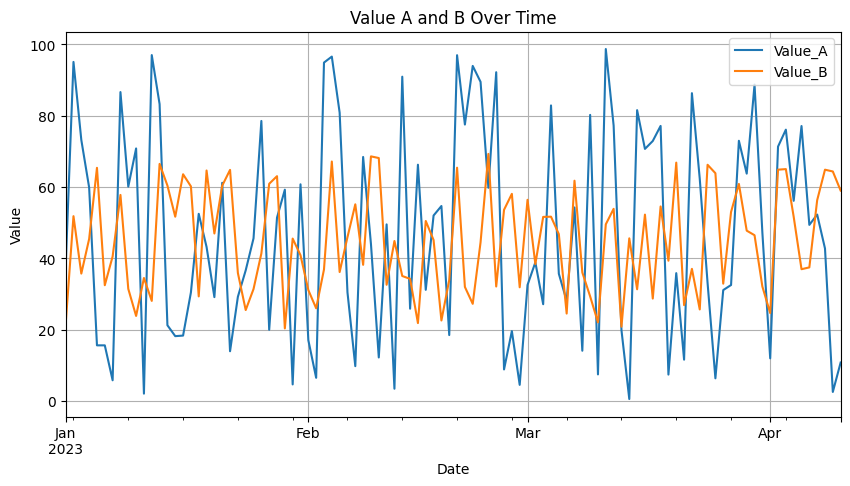

In [33]:
# 6.1 Line Plot
print("\n6.1 Line Plot (Time Series Data)")
plot_df[['Value_A', 'Value_B']].plot(figsize=(10, 5), title='Value A and B Over Time')
plt.ylabel('Value')
plt.grid(True)
plt.show()


6.2 Bar Plot (Category Counts)


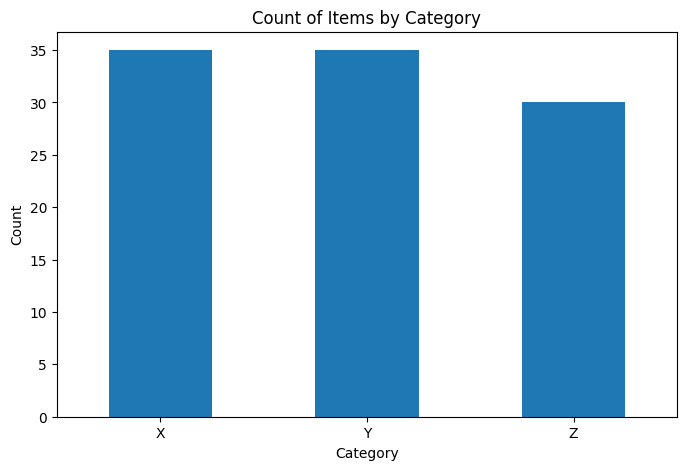

In [34]:
# 6.2 Bar Plot
print("\n6.2 Bar Plot (Category Counts)")
bar_chart_data.plot(kind='bar', figsize=(8, 5), title='Count of Items by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


6.3 Barh Plot (Group Scores by Category - Mean)


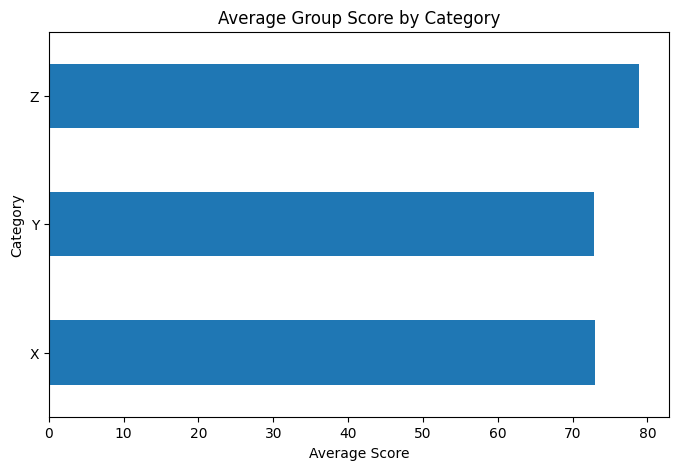

In [35]:
# 6.3 Barh Plot (Horizontal Bar Plot)
print("\n6.3 Barh Plot (Group Scores by Category - Mean)")
plot_df.groupby('Category')['Group_Score'].mean().plot(kind='barh', figsize=(8, 5), title='Average Group Score by Category')
plt.xlabel('Average Score')
plt.ylabel('Category')
plt.show()


6.4 Histogram (Distribution of Value_A)


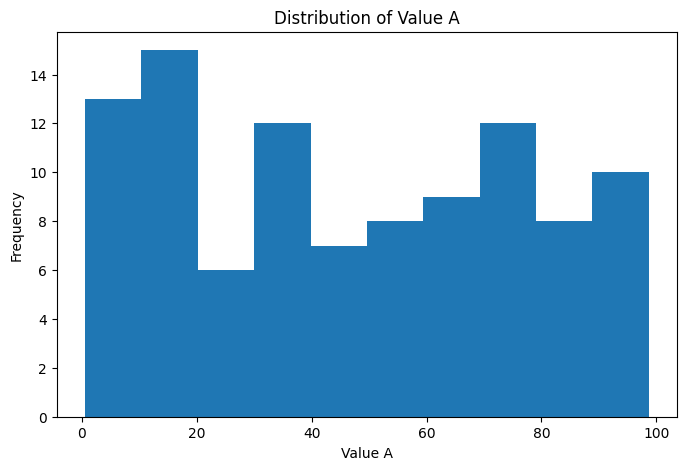

In [36]:
# 6.4 Histogram
print("\n6.4 Histogram (Distribution of Value_A)")
plot_df['Value_A'].plot(kind='hist', bins=10, figsize=(8, 5), title='Distribution of Value A')
plt.xlabel('Value A')
plt.ylabel('Frequency')
plt.show()


6.5 Box Plot (Value_A by Category)


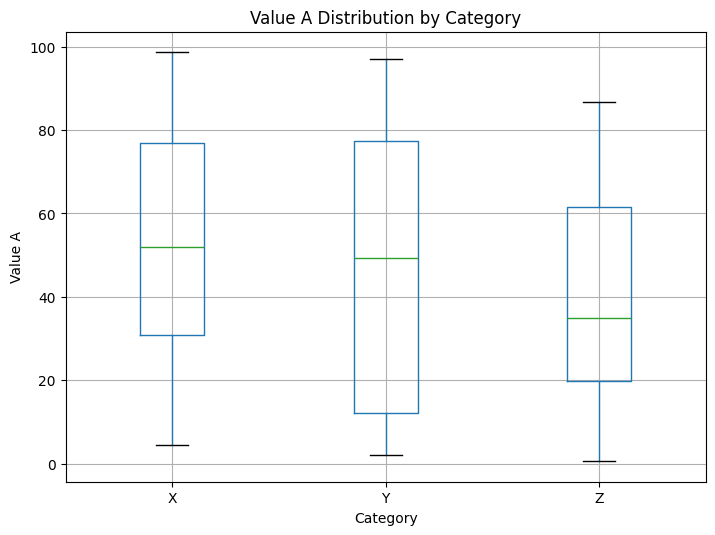

In [37]:
# 6.5 Box Plot
print("\n6.5 Box Plot (Value_A by Category)")
plot_df.boxplot(column='Value_A', by='Category', figsize=(8, 6))
plt.suptitle('') # Suppress the default suptitle created by boxplot
plt.title('Value A Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Value A')
plt.show()


6.6 Area Plot (Stacked Area of Value_A and Value_B)


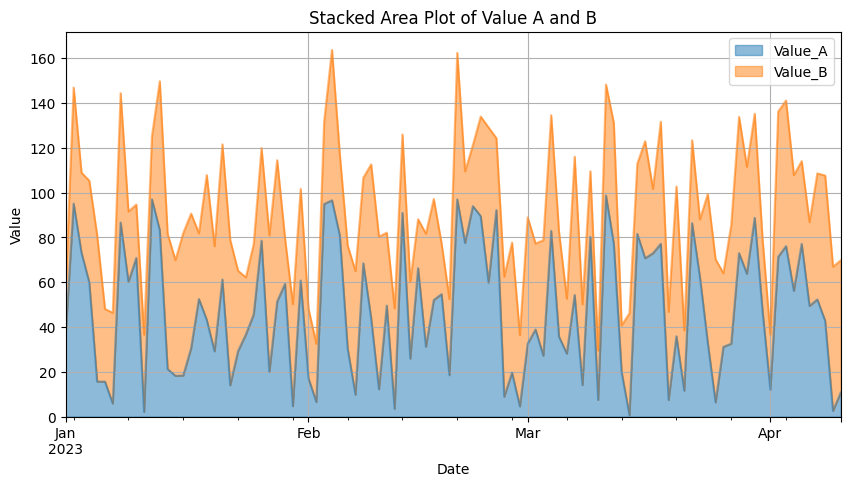

In [38]:

# 6.6 Area Plot
print("\n6.6 Area Plot (Stacked Area of Value_A and Value_B)")
# For area plot, ensure data is sorted by index (Date here)
plot_df[['Value_A', 'Value_B']].plot(kind='area', stacked=True, alpha=0.5, figsize=(10, 5), title='Stacked Area Plot of Value A and B')
plt.ylabel('Value')
plt.grid(True)
plt.show()


6.7 Density Plot (KDE for Value_A and Value_B)


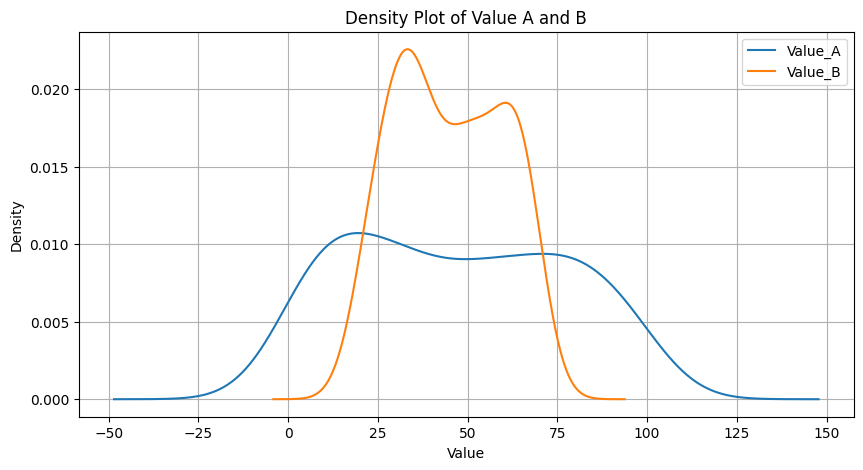

In [39]:
# 6.7 Density Plot (KDE - Kernel Density Estimate)
print("\n6.7 Density Plot (KDE for Value_A and Value_B)")
plot_df[['Value_A', 'Value_B']].plot(kind='kde', figsize=(10, 5), title='Density Plot of Value A and B')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(True)
plt.show()


6.8 Scatter Plot (Value_A vs Value_B)


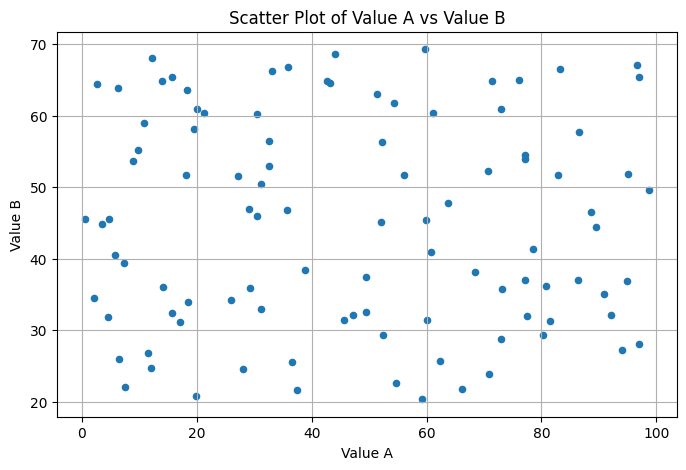

In [40]:
# 6.8 Scatter Plot
print("\n6.8 Scatter Plot (Value_A vs Value_B)")
plot_df.plot(kind='scatter', x='Value_A', y='Value_B', figsize=(8, 5), title='Scatter Plot of Value A vs Value B')
plt.xlabel('Value A')
plt.ylabel('Value B')
plt.grid(True)
plt.show()


6.9 Hexbin Plot (Value_A vs Value_B with Density)


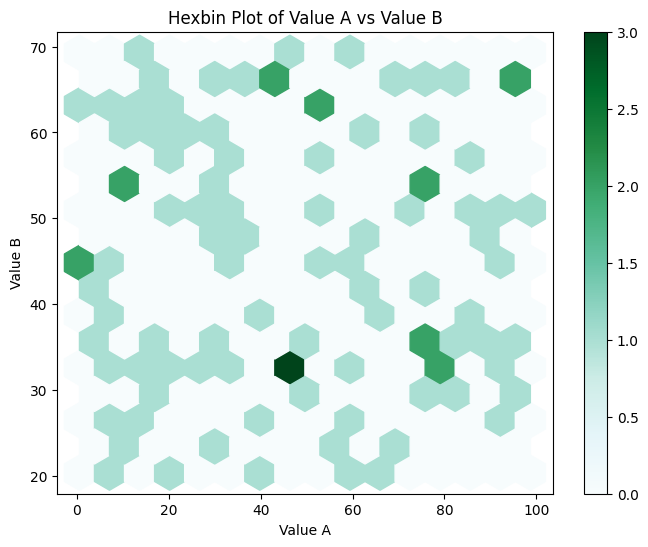

In [41]:
# 6.9 Hexbin Plot (for dense scatter plots)
print("\n6.9 Hexbin Plot (Value_A vs Value_B with Density)")
plot_df.plot(kind='hexbin', x='Value_A', y='Value_B', gridsize=15, figsize=(8, 6), title='Hexbin Plot of Value A vs Value B')
plt.xlabel('Value A')
plt.ylabel('Value B')
plt.show()



6.10 Pie Chart (Proportion of Value_A by Category)


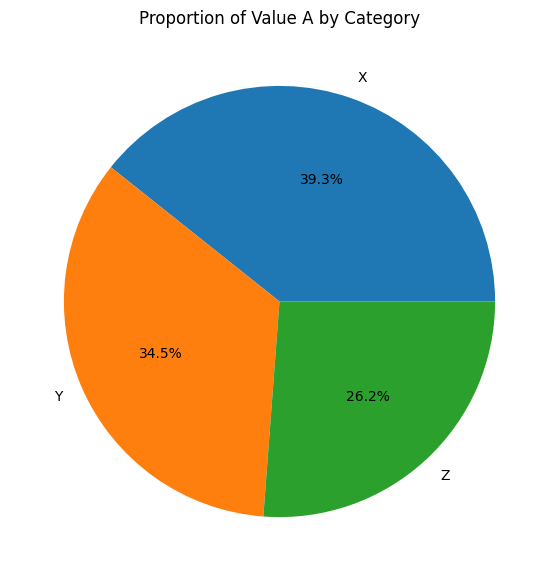

In [42]:
# 6.10 Pie Chart
print("\n6.10 Pie Chart (Proportion of Value_A by Category)")
pie_chart_data.plot(kind='pie', autopct='%1.1f%%', figsize=(7, 7), title='Proportion of Value A by Category')
plt.ylabel('') # Hide the default 'Value_A' label
plt.show()
